# Real Time Gate Fraud Pattern Detection using Sliding Window (Deque)

This project simulates railway ticket scan activity and uses a deque based sliding window to detect suspicious short term behaviour. It tracks the most recent scans, calculates rolling risk signals, raises alerts, and visualises how risk changes over time. This mirrors real world fraud monitoring

Railway operators process thousands of ticket scans per hour.

Fraud or misuse often does not appear in full historical data but in short bursts of abnormal behaviour.

We need a system that:

Detects suspicious activity in real-time using only the most recent events.

Core Idea
```
Using deque to:
store last N scans (sliding window)
compute metrics on the fly
trigger alerts when patterns emerge

Building a mini real-time monitoring system (Only look at the most recent N scans)
```
Core part:
```
recent_scans = deque(maxlen=WINDOW_SIZE)
```
Means: It means:
“Always keep only the last _(e.g.8) scans”

### Data Structure

Each scan contains:

```
{
    "timestamp": int, #When did this happen?
    "amount": float, #How much did they pay? (abnormal drop=strong signal)
    "status": "allowed" or "blocked", #Did the gate accept the ticket?
    "ticket_type": "adult" / "child" / "railcard",
    "confidence": float  # model confidence (unstable confiidence = unreliable model.. Sudden drops=data drift)
}
```

```
ticket scans → model predictions
amount → feature values
status → prediction outcome
```

```
For every new scan:
Generate one scan event
Add it to the deque
If deque is full, oldest scan disappears automatically
Analyse only the recent scans in the deque
Calculate metrics
Create alerts if suspicious patterns appear
Save the result into records
At the end, turn all saved results into a pandas DataFrame
```

In [2]:
from collections import deque
import random #fake data creation
import pandas as pd
import matplotlib.pyplot as plt

random.seed(42) #Each time I run the code, I should get the same fake data.
WINDOW_SIZE = 8
recent_scans = deque(maxlen=WINDOW_SIZE)
#The deque can only keep the most recent 8 scans. So if 10 scans arrive, the first 2 will eventually get pushed out. This is your first full sliding window.From here on, every new scan removes the oldest one automatically.for e.g. if we get (scan9) deque removes scan1.

def generate_scan(t): #t stands for timestamp
    """
    Simulate one railway ticket scan event.
    Most events are normal, but some are intentionally suspicious.
    """
    suspicious_mode = random.random() < 0.3 #gives random number between 0 and 1.. (since we are not using real data)...then we check if its less than 0.3..

    if suspicious_mode:
        amount = round(random.uniform(0.2, 2.5), 2)
        status = random.choices(["allowed", "blocked"], weights=[0.3, 0.7])[0]
        confidence = round(random.uniform(0.45, 0.95), 2)
        ticket_type = random.choice(["child", "railcard", "adult"])
    else:
        amount = round(random.uniform(5, 18), 2)
        status = random.choices(["allowed", "blocked"], weights=[0.85, 0.15])[0]
        confidence = round(random.uniform(0.75, 0.99), 2)
        ticket_type = random.choice(["adult", "adult", "railcard"])

#return the scan as a dictionary
    return {
        "timestamp": t,
        "amount": amount,
        "status": status,
        "ticket_type": ticket_type,
        "confidence": confidence
    }
# if its status is 'blocked, count 1.
def analyse_window(window):
    """
    Analyse the current sliding window and return metrics and alerts.
    """
    blocked_count = sum(1 for x in window if x["status"] == "blocked") # if its status is 'blocked, count 1.
    avg_price = sum(x["amount"] for x in window) / len(window)
    low_price_count = sum(1 for x in window if x["amount"] < 3) #Count how many scans in the window have amount less than 3.
    confidence_range = max(x["confidence"] for x in window) - min(x["confidence"] for x in window)

    risk_score = 0
    alerts = []

    if blocked_count >= 4:
        risk_score += 3 #add 3 points to risk score
        alerts.append("High blocked scan volume")


    if avg_price < 5:
        risk_score += 2
        alerts.append("Average ticket price unusually low")

    if low_price_count >= 3:
        risk_score += 2
        alerts.append("Repeated low value ticket usage")

    if confidence_range > 0.35:
        risk_score += 1
        alerts.append("Confidence instability detected")

    if blocked_count >= 4 and low_price_count >= 3:
        risk_score += 2
        alerts.append("Possible coordinated fraud pattern")

    return {
        "blocked_count": blocked_count,
        "avg_price": round(avg_price, 2),
        "low_price_count": low_price_count,
        "confidence_range": round(confidence_range, 2),
        "risk_score": risk_score,
        "alerts": alerts
    }

records = []

for t in range(1, 61): #in this project, i am only simulating 60 scan. but in real life it would be continuous (infitine)
    scan = generate_scan(t)
    recent_scans.append(scan)

    metrics = analyse_window(recent_scans)

    row = {
        "timestamp": t,
        "amount": scan["amount"],
        "status": scan["status"],
        "ticket_type": scan["ticket_type"],
        "confidence": scan["confidence"],
        "window_size": len(recent_scans),
        "blocked_count": metrics["blocked_count"],
        "avg_price": metrics["avg_price"],
        "low_price_count": metrics["low_price_count"],
        "confidence_range": metrics["confidence_range"],
        "risk_score": metrics["risk_score"],
        "alert_count": len(metrics["alerts"]),
        "alerts": ", ".join(metrics["alerts"]) if metrics["alerts"] else "No alert"
    }

    records.append(row)

df = pd.DataFrame(records)

print(df.head(10))

   timestamp  amount   status ticket_type  confidence  window_size  \
0          1    5.33  allowed    railcard        0.80            1   
1          2    1.90  blocked       child        0.75            2   
2          3    0.70  blocked       child        0.46            3   
3          4   14.12  allowed       adult        0.86            4   
4          5    5.08  allowed       adult        0.92            5   
5          6    0.70  blocked    railcard        0.50            6   
6          7    2.15  blocked       adult        0.85            7   
7          8    6.62  blocked       adult        0.77            8   
8          9   13.04  blocked    railcard        0.89            8   
9         10    1.72  blocked       child        0.94            8   

   blocked_count  avg_price  low_price_count  confidence_range  risk_score  \
0              0       5.33                0              0.00           0   
1              1       3.62                1              0.05           

Deque is useful for real time monitoring result for;
- real time alerts without saving everything
- small window
- for speed and computing cost
- detect current behaviour. it can be used for answering 'what is happening right now?'

In [3]:
suspicious_df = df[df["risk_score"] >= 4].copy()
print(suspicious_df[[
    "timestamp",
    "amount",
    "status",
    "confidence",
    "blocked_count",
    "avg_price",
    "low_price_count",
    "confidence_range",
    "risk_score",
    "alerts"
]].head(15))

    timestamp  amount   status  confidence  blocked_count  avg_price  \
5           6    0.70  blocked        0.50              3       4.64   
6           7    2.15  blocked        0.85              4       4.28   
7           8    6.62  blocked        0.77              5       4.58   
8           9   13.04  blocked        0.89              6       5.54   
9          10    1.72  blocked        0.94              6       5.52   
10         11    9.94  allowed        0.95              5       6.67   
11         12    7.72  allowed        0.97              5       5.87   
12         13    1.66  blocked        0.57              6       5.44   
13         14   17.86  allowed        0.88              5       7.59   
14         15   14.99  allowed        0.95              4       9.19   
15         16    5.86  blocked        0.89              4       9.10   
28         29    0.75  blocked        0.49              4       7.96   
39         40    1.70  blocked        0.48              3       

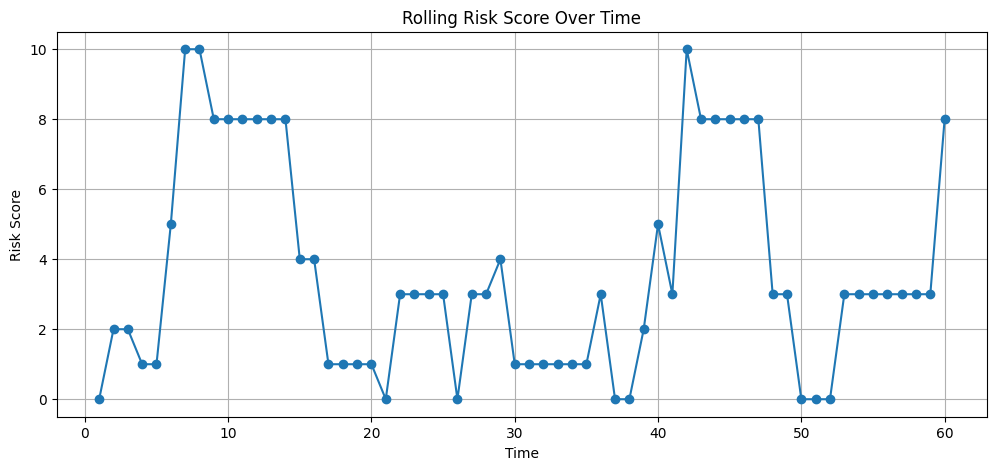

In [4]:
plt.figure(figsize=(12, 5))
plt.plot(df["timestamp"], df["risk_score"], marker="o")
plt.xlabel("Time")
plt.ylabel("Risk Score")
plt.title("Rolling Risk Score Over Time")
plt.grid(True)
plt.show()

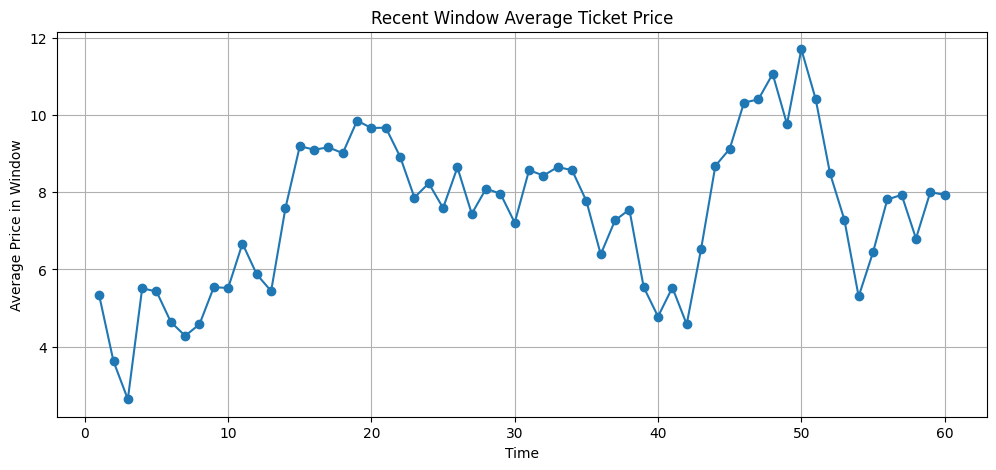

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(df["timestamp"], df["avg_price"], marker="o")
plt.xlabel("Time")
plt.ylabel("Average Price in Window")
plt.title("Recent Window Average Ticket Price")
plt.grid(True)
plt.show()

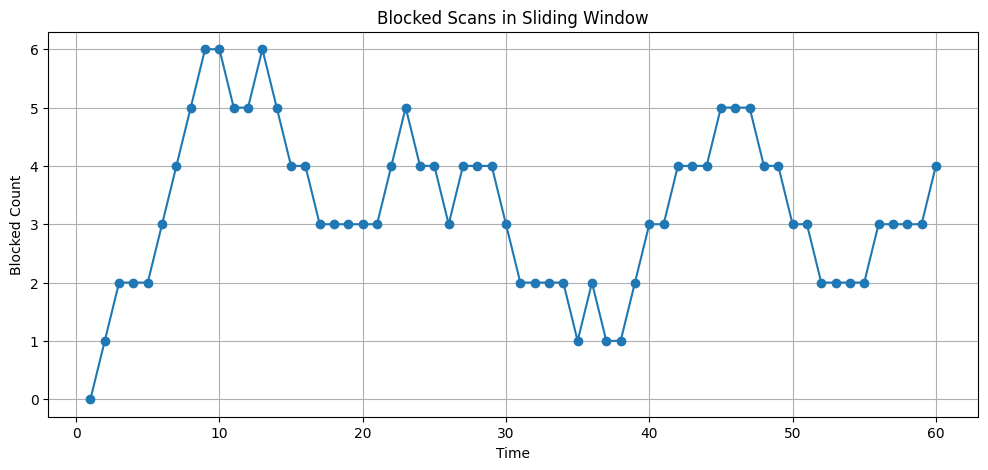

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(df["timestamp"], df["blocked_count"], marker="o")
plt.xlabel("Time")
plt.ylabel("Blocked Count")
plt.title("Blocked Scans in Sliding Window")
plt.grid(True)
plt.show()

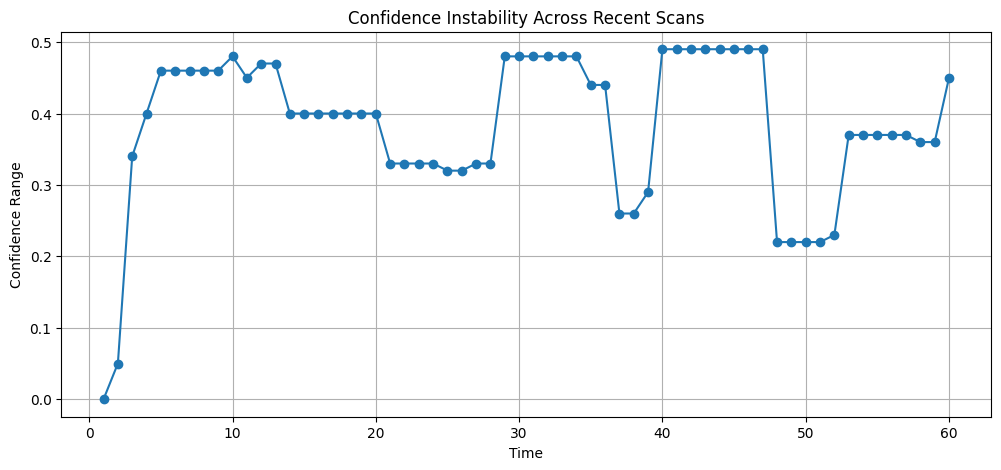

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(df["timestamp"], df["confidence_range"], marker="o")
plt.xlabel("Time")
plt.ylabel("Confidence Range")
plt.title("Confidence Instability Across Recent Scans")
plt.grid(True)
plt.show()

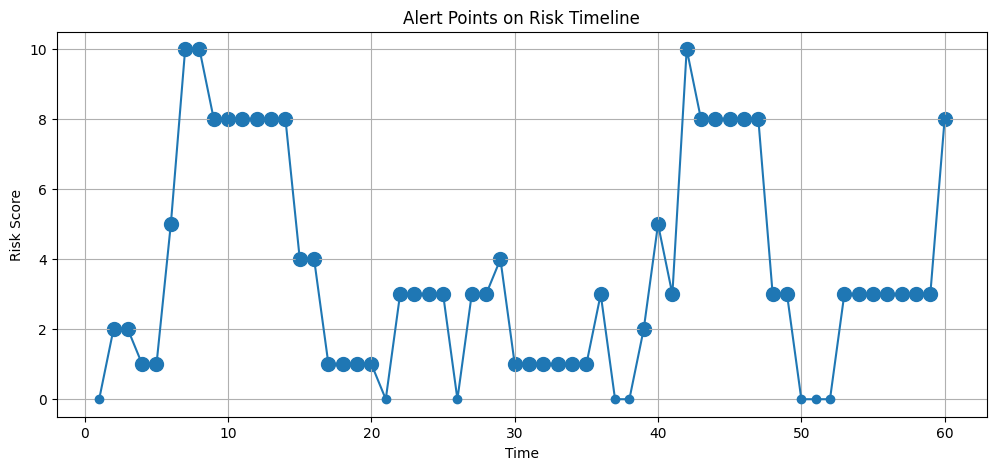

In [8]:
alert_points = df[df["alert_count"] > 0]

plt.figure(figsize=(12, 5))
plt.plot(df["timestamp"], df["risk_score"], marker="o")
plt.scatter(alert_points["timestamp"], alert_points["risk_score"], s=100)
plt.xlabel("Time")
plt.ylabel("Risk Score")
plt.title("Alert Points on Risk Timeline")
plt.grid(True)
plt.show()

In [9]:
df[[
    "timestamp",
    "amount",
    "status",
    "ticket_type",
    "confidence",
    "blocked_count",
    "avg_price",
    "low_price_count",
    "confidence_range",
    "risk_score",
    "alerts"
]].tail(15)

,timestamp,amount,status,ticket_type,confidence,blocked_count,avg_price,low_price_count,confidence_range,risk_score,alerts
45,46,17.81,allowed,adult,0.94,5,10.32,3,0.49,8,"High blocked scan volume, Repeated low value t..."
46,47,1.80,blocked,adult,0.84,5,10.40,3,0.49,8,"High blocked scan volume, Repeated low value t..."
47,48,7.01,allowed,railcard,0.98,4,11.06,2,0.22,3,High blocked scan volume
48,49,5.79,allowed,adult,0.76,4,9.76,2,0.22,3,High blocked scan volume
49,50,16.09,allowed,adult,0.98,3,11.70,1,0.22,0,No alert
50,51,5.89,allowed,adult,0.96,3,10.41,1,0.22,0,No alert
51,52,2.25,allowed,adult,0.75,2,8.49,2,0.23,0,No alert
52,53,1.71,blocked,railcard,0.61,2,7.29,3,0.37,3,"Repeated low value ticket usage, Confidence in..."
53,54,1.85,allowed,adult,0.65,2,5.30,4,0.37,3,"Repeated low value ticket usage, Confidence in..."
54,55,10.94,blocked,adult,0.97,2,6.44,3,0.37,3,"Repeated low value ticket usage, Confidence in..."


“This is a simplified version of real-time validation logic (using simulation data)